In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.layers import Dense, Concatenate
import scipy.stats as ss
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [28]:
# Load the data from csv files
df = pd.read_csv("../test_files/test_4ring/test_4ring.csv")
ka_mat = np.loadtxt("../test_files/test_4ring/test_4ring_ka_mat.nptxt")
ka_contrib = np.loadtxt("../test_files/test_4ring/test_4ring_rate_contrib_mat.nptxt")
x = df["seq"].values
y = df["raw_activity"].values

enc = OneHotEncoder(categories=[["A", "B"]], sparse=False)

# Encode sequences as one-hot vectors
# sequences = ['ABAB', 'BBAA']
n_samples = len(x)
seq_length = len(x[0])  # Assuming all sequences have the same length
flat = np.array([list(seq) for seq in x]).flatten()[:, None]
encoded = enc.fit_transform(flat)
x = encoded.reshape(n_samples, seq_length, 2)  # shape: (n_samples, seq_length, 2)
print(ka_mat)

[[0. 1. 0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 0.]
 [1. 0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 1. 0.]
 [1. 0. 1. 0. 1. 0. 0.]]


In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=777
)

In [30]:
# Model
model = keras.Sequential(
    [
        layers.Input(shape=(seq_length, 2)),  # one-hot encoded 'A'/'B' per position
        layers.Flatten(),
        layers.Dense(7, activation="relu"),  # hidden layer
        layers.Dense(1, activation="relu"),  # output: positive float
    ]
)
model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=40, batch_size=32, validation_data=(x_test, y_test)
)


Train on 1600 samples, validate on 400 samples
Epoch 1/40
1600/1600 [==============================] - 0s 136us/sample - loss: 0.0053 - val_loss: 0.0030
Epoch 2/40
1600/1600 [==============================] - 0s 25us/sample - loss: 0.0030 - val_loss: 0.0028
Epoch 3/40
1600/1600 [==============================] - 0s 23us/sample - loss: 0.0029 - val_loss: 0.0028
Epoch 4/40
1600/1600 [==============================] - 0s 24us/sample - loss: 0.0029 - val_loss: 0.0028
Epoch 5/40
1600/1600 [==============================] - 0s 22us/sample - loss: 0.0029 - val_loss: 0.0028
Epoch 6/40
1600/1600 [==============================] - 0s 22us/sample - loss: 0.0029 - val_loss: 0.0028
Epoch 7/40
1600/1600 [==============================] - 0s 22us/sample - loss: 0.0029 - val_loss: 0.0028
Epoch 8/40
1600/1600 [==============================] - 0s 25us/sample - loss: 0.0029 - val_loss: 0.0028
Epoch 9/40
1600/1600 [==============================] - 0s 23us/sample - loss: 0.0029 - val_loss: 0.0028
Epoch 1

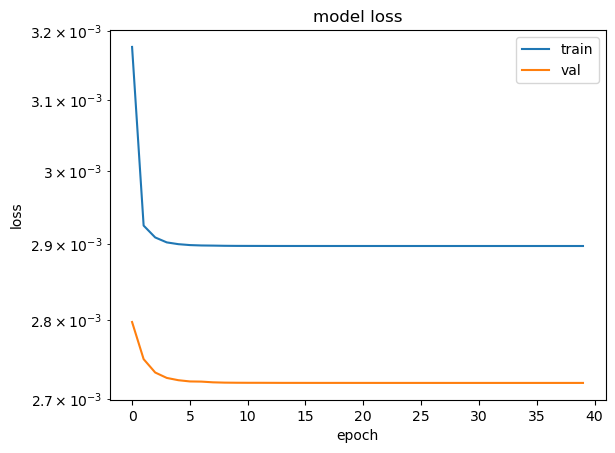

In [6]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")

In [31]:
# Model
model = keras.Sequential(
    [
        layers.Input(shape=(seq_length, 2)),  # one-hot encoded 'A'/'B' per position
        layers.Flatten(),
        layers.Dense(7, activation="relu"),  # hidden layer
        layers.Dense(10, activation="softmax"),  # hidden layer
        layers.Dense(1, activation="linear"),  # output: positive float
    ]
)
model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 0s 168us/sample - loss: 0.0041 - val_loss: 0.0025
Epoch 2/500
1600/1600 [==============================] - 0s 29us/sample - loss: 0.0018 - val_loss: 9.8900e-04
Epoch 3/500
1600/1600 [==============================] - 0s 25us/sample - loss: 6.2466e-04 - val_loss: 2.8146e-04
Epoch 4/500
1600/1600 [==============================] - 0s 24us/sample - loss: 2.1051e-04 - val_loss: 1.1893e-04
Epoch 5/500
1600/1600 [==============================] - 0s 27us/sample - loss: 9.6091e-05 - val_loss: 6.4861e-05
Epoch 6/500
1600/1600 [==============================] - 0s 26us/sample - loss: 5.5504e-05 - val_loss: 4.3409e-05
Epoch 7/500
1600/1600 [==============================] - 0s 26us/sample - loss: 3.8459e-05 - val_loss: 3.3325e-05
Epoch 8/500
1600/1600 [==============================] - 0s 24us/sample - loss: 2.8881e-05 - val_loss: 2.6052e-05
Epoch 9/500
1600/1600 [=============================

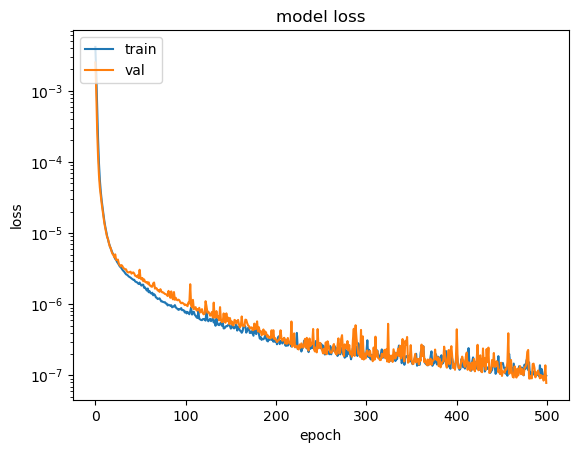

In [32]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.yscale("log")

In [33]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_4 (Flatten)          (None, 14)                0         
_________________________________________________________________
dense_7 (Dense)              (None, 7)                 105       
_________________________________________________________________
dense_8 (Dense)              (None, 10)                80        
_________________________________________________________________
dense_9 (Dense)              (None, 1)                 11        
Total params: 196
Trainable params: 196
Non-trainable params: 0
_________________________________________________________________


In [34]:
# Model
inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(7, activation="linear", name="log_rates")(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/500
1600/1600 [==============================] - 0s 195us/sample - loss: 0.0084 - val_loss: 0.0034
Epoch 2/500
1600/1600 [==============================] - 0s 25us/sample - loss: 0.0025 - val_loss: 0.0018
Epoch 3/500
1600/1600 [==============================] - 0s 24us/sample - loss: 0.0016 - val_loss: 0.0014
Epoch 4/500
1600/1600 [==============================] - 0s 26us/sample - loss: 0.0012 - val_loss: 0.0010
Epoch 5/500
1600/1600 [==============================] - 0s 27us/sample - loss: 9.2066e-04 - val_loss: 7.4291e-04
Epoch 6/500
1600/1600 [==============================] - 0s 23us/sample - loss: 6.7304e-04 - val_loss: 5.3409e-04
Epoch 7/500
1600/1600 [==============================] - 0s 23us/sample - loss: 4.8683e-04 - val_loss: 3.8585e-04
Epoch 8/500
1600/1600 [==============================] - 0s 23us/sample - loss: 3.5385e-04 - val_loss: 2.8204e-04
Epoch 9/500
1600/1600 [==============================] -

Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 7, 2)]       0                                            
__________________________________________________________________________________________________
flatten_5 (Flatten)             (None, 14)           0           input_6[0][0]                    
__________________________________________________________________________________________________
log_rates (Dense)               (None, 7)            105         flatten_5[0][0]                  
__________________________________________________________________________________________________
KA_terms (Lambda)               (None, 10)           0           log_rates[0][0]                  
____________________________________________________________________________________________

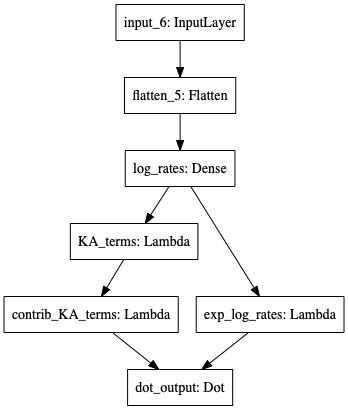

In [35]:
model.summary()
tf.keras.utils.plot_model(model)

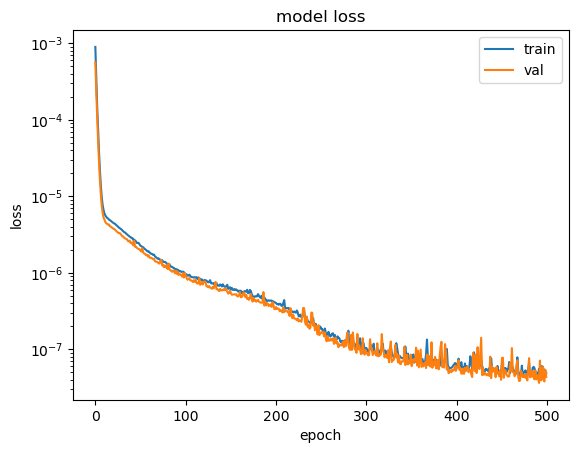

In [13]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")

In [ ]:
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()
# print(weights.shape, biases.shape)
# print(np.max(np.exp(weights.T), axis=1))

test_arr = np.zeros(14)
test_arr[::2] = 1.0
print("Test array:", test_arr)
weights = np.array(weights)
print("biases")
print(np.exp(biases))
print("Weights shape:", weights.shape)
print("Weights:", weights)
results = np.matmul(test_arr, weights) + biases
print("Results for test array:", results)
print("Rates:", np.exp(results))

Test array: [1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.]
biases
[1.0144961 1.1495994 1.0225239 1.0196972 1.0475091 1.2053787 0.8877588]
Weights shape: (14, 7)
Weights: [[ 0.23273446  0.25052717  0.34935617  0.30456042  0.2954173   0.34325317 -0.30095702]
 [-0.31118008  0.05096683  0.10434499  0.29953444 -0.08597567  0.30918297  0.03981313]
 [ 0.3677309  -0.03775103 -0.04958686 -0.50332767  0.45071504 -0.031172   -0.26903597]
 [ 0.21037994  0.59225553 -0.20908923  0.00724547 -0.32206097 -0.2678429   0.26230478]
 [ 0.23226541 -0.32630157 -0.31352797  0.4424796   0.41702038 -0.26493838  0.15774485]
 [ 0.04771115  0.01904008  0.22820552  0.2590404  -0.4416984   0.07447368  0.25167415]
 [-0.04451996 -0.2259064   0.06022579 -0.20785391  0.00623126 -0.05027922  0.41317692]
 [ 0.00076827  0.1376822  -0.2036777   0.02296233 -0.08297148  0.20743722 -0.15385611]
 [-0.35951042 -0.00221249  0.21943705 -0.05103026 -0.39367554  0.11555507 -0.01099455]
 [-0.48104808 -0.12261571  0.02902619  0.30701777 

In [15]:
k = np.exp(results)
rate_matrix = -np.array(
    [
        [-k[0], k[1], 0, k[6]],
        [k[0], -(k[1] + k[2]), k[3], 0, ],
        [0, k[2], -(k[3] + k[4]), k[5]],
        [0, 0, k[4], -(k[5] + k[6])],
    ]
)

np.linalg.eig(rate_matrix)
print("Rate matrix:")
kernel = null_space(rate_matrix)
kernel = kernel / np.sum(kernel)  # Normalize the kernel
kernel[-1]*k[-1]

Rate matrix:


array([0.09982463])

In [21]:
x = np.array([[1, 0]]*7).reshape(1, 7, 2)  # Example input
print("Input x:", x)
# print(x)
# print("Input x shape:", x.shape)
y = model.predict(x)
print("Predicted y:", y)
x2 = np.array([[1, 0]]*7).reshape(1, 7, 2)  # Example input
x2[0,0] = np.array([0, 1])  # Change the first position to 'B'
print("Input x2:", x2)
y2 = model.predict(x2)
print("Predicted y2:", y2)

Input x: [[[1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]]]
Predicted y: [[0.09982464]]
Input x2: [[[0 1]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]]]
Predicted y2: [[0.0715415]]


In [ ]:
from tensorflow.keras import Model
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Activation output:", np.exp(activation_output))

Activation output: [[0.7590337 0.8665507 1.3416135 1.40177   2.9504464 1.8596911 0.5062471]]


In [ ]:
from tensorflow.keras import Model
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x2)
print("Activation output:", np.exp(activation_output))

Activation output: [[0.44059744 0.70978373 1.0500752  1.3947423  2.0148876  1.7973983  0.71179855]]


In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri Jul 04 2025

Python implementation: CPython
Python version       : 3.7.3
IPython version      : 7.33.0

numpy     : 1.18.5
scipy     : 1.5.3
matplotlib: 3.5.1
pandas    : 1.3.5
sklearn   : 1.0.2
tensorflow: 1.14.0
seaborn   : 0.12.2

Watermark: 2.5.0

